# BPMA versus standard classifiers

Compare BPMA, k-NN, random forest, and RBF SVM on standard scikit-learn datasets.

In [1]:
import sys
from pathlib import Path
import warnings
from IPython.display import display

warnings.filterwarnings(
    "ignore",
    message="A worker stopped while some jobs were given to the executor.*",
    category=UserWarning,
)

project_root = Path.cwd()
if not (project_root / "bayesian_model_averaging").is_dir() and (project_root.parent / "bayesian_model_averaging").is_dir():
    project_root = project_root.parent
if (project_root / "bayesian_model_averaging").is_dir():
    sys.path.insert(0, str(project_root))

from bayesian_model_averaging.experiments.classifier_comparison import (
    comparison_results_dataframe,
    plot_comparison_results,
    run_comparison_suite,
)
from bayesian_model_averaging import default_family_registry

In [2]:
DATASETS = ("iris", "wine", "breast_cancer", "digits")

COMPARISON_PARAMETERS = {
    "test_size": 0.25,
    "n_repeats": 5,
    "random_state": 7,
    "n_neighbors": 15,
    "bayesian_parameters": {
        "n_estimators": "auto",
        "max_estimators": 1000,
        "tolerance": 0.001,
        "convergence_metric": "median",
        "convergence_size": 256,
        "cv": 5,
        "family_registry": default_family_registry(),
        "n_jobs": -1,
        "random_state": 12,
    },
    "random_forest_parameters": {
        "n_estimators": 300,
        "n_jobs": -1,
    },
    "svm_parameters": {
        "C": 1.0,
        "kernel": "rbf",
    },
}

PLOT_PARAMETERS = {
    "metric": "accuracy",
    "output_path": None,
}

accuracy_mean  balanced_accuracy_mean  \
dataset       classifier                                                        
breast_cancer BPMA         0.9748                  0.9684   
              Random forest                    0.9678                  0.9620   
              SVM                              0.9818                  0.9809   
              k-NN                             0.9678                  0.9597   
digits        BPMA         0.9756                  0.9755   
              Random forest                    0.9796                  0.9794   
              SVM                              0.9836                  0.9834   
              k-NN                             0.9702                  0.9700   
iris          BPMA         0.9526                  0.9513   
              Random forest                    0.9526                  0.9513   
              SVM                              0.9526                  0.9513   
              k-NN                             0.9526                  0.9513   
wine          BPMA         0.9956                  0.9963   
              Random forest                    0.9867                  0.9889   
              SVM                              0.9867                  0.9874   
              k-NN                             0.9733                  0.9778   

                                        macro_f1_mean  accuracy_std  \
dataset       classifier                                              
breast_cancer BPMA         0.9727        0.0127   
              Random forest                    0.9652        0.0080   
              SVM                              0.9806        0.0106   
              k-NN                             0.9651        0.0038   
digits        BPMA         0.9755        0.0047   
              Random forest                    0.9794        0.0029   
              SVM                              0.9835        0.0046   
              k-NN                             0.9700        0.0118   
iris          BPMA         0.9519        0.0288   
              Random forest                    0.9519        0.0288   
              SVM                              0.9519        0.0288   
              k-NN                             0.9519        0.0288   
wine          BPMA         0.9954        0.0099   
              Random forest                    0.9872        0.0199   
              SVM                              0.9872        0.0122   
              k-NN                             0.9744        0.0243   

                                        balanced_accuracy_std  macro_f1_std  
dataset       classifier                                                     
breast_cancer BPMA                 0.0168        0.0139  
              Random forest                            0.0124        0.0089  
              SVM                                      0.0098        0.0113  
              k-NN                                     0.0028        0.0040  
digits        BPMA                 0.0047        0.0048  
              Random forest                            0.0029        0.0029  
              SVM                                      0.0046        0.0047  
              k-NN                                     0.0120        0.0121  
iris          BPMA                 0.0297        0.0296  
              Random forest                            0.0297        0.0296  
              SVM                                      0.0297        0.0296  
              k-NN                                     0.0297        0.0296  
wine          BPMA                 0.0083        0.0102  
              Random forest                            0.0166        0.0194  
              SVM                                      0.0116        0.0117  
              k-NN                                     0.0203        0.0234

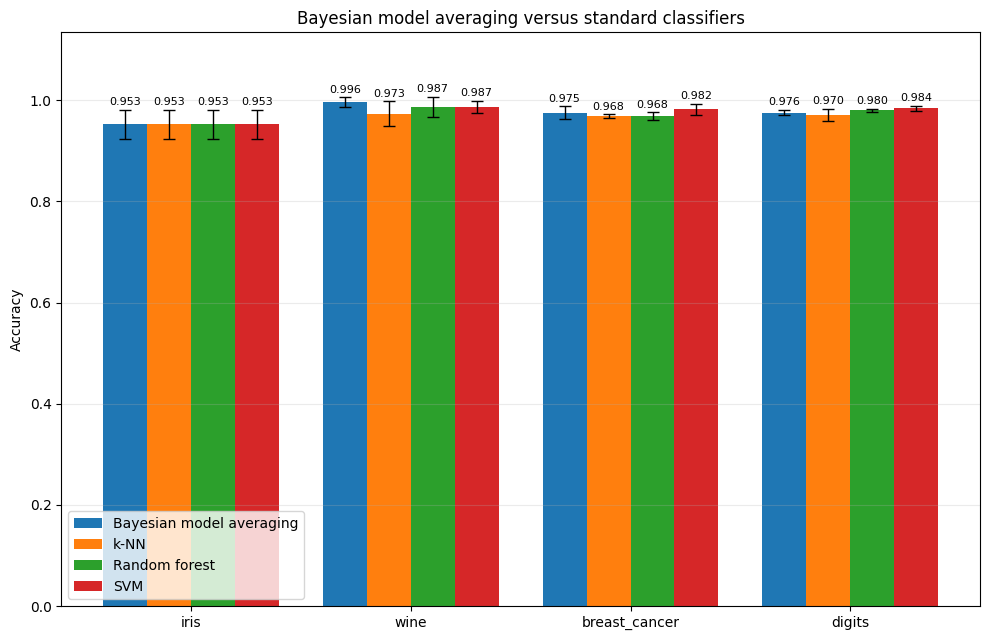

In [3]:
results = run_comparison_suite(DATASETS, **COMPARISON_PARAMETERS)
display(comparison_results_dataframe(results))
_ = plot_comparison_results(results, **PLOT_PARAMETERS)